In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot

In [15]:
df = pd.read_csv("spread_locator_dataset.csv")

df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [19]:
df=df.dropna(subset=['transaction_amount'])
df['transaction_count']=df['transaction_count'].fillna(0)

In [34]:
#Bernoulli Distribution
df['success']=df['transaction_status'].apply(lambda x: 1 if x=='Success' else 0)


In [36]:
p=df['success'].mean()
print("Probablity of Success",p)

Probablity of Success 0.44545454545454544


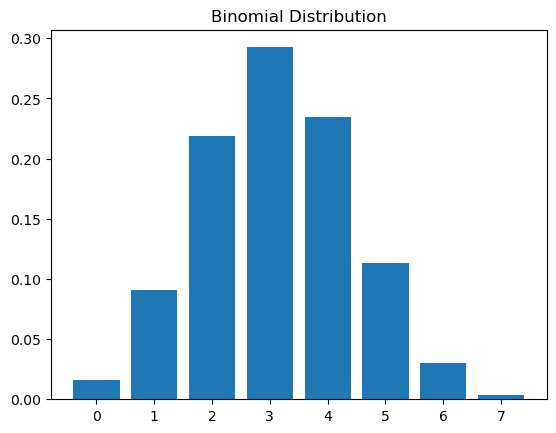

In [46]:
#Binomial Distribution 
n=7
p=df['success'].mean()

binominal_probs=stats.binom.pmf(range(0,8),n,p)

plt.bar(range(0,8),binominal_probs)
plt.title("Binomial Distribution")
plt.show()

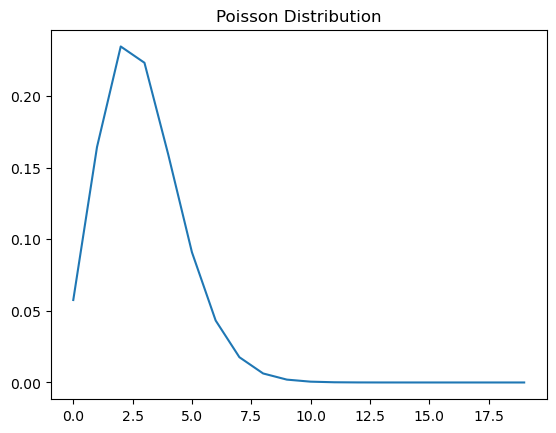

In [47]:
#Poisson Distribution (Daily Transactions)
lambda_ = df['transaction_count'].mean()

x = np.arange(0, 20)
poisson_probs = stats.poisson.pmf(x, lambda_)

plt.plot(x, poisson_probs)
plt.title("Poisson Distribution")
plt.show()

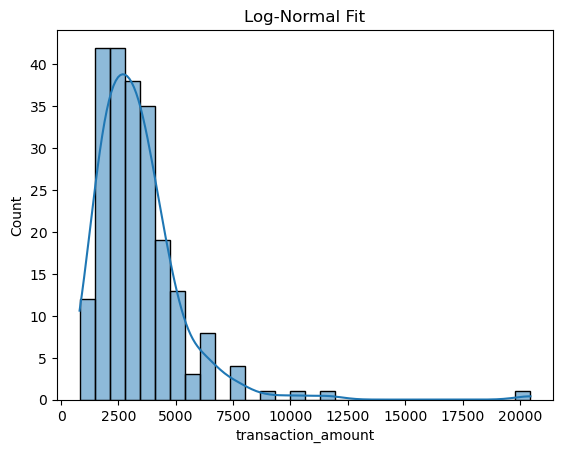

In [48]:
# Log-Normal Distribution
shape, loc, scale = stats.lognorm.fit(df['transaction_amount'])

sns.histplot(df['transaction_amount'], kde=True)
plt.title("Log-Normal Fit")
plt.show()

In [49]:
# Power Law Distribution
params = stats.powerlaw.fit(df['transaction_amount'])

print("Power Law Parameters:", params)

Power Law Parameters: (np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


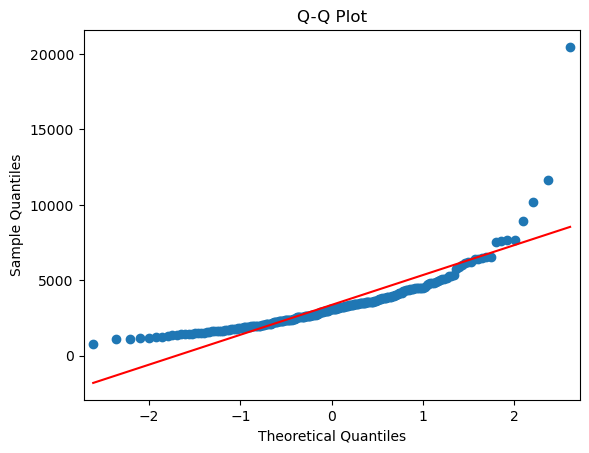

In [50]:
# Q-Q Plot
qqplot(df['transaction_amount'], line='s')
plt.title("Q-Q Plot")
plt.show()

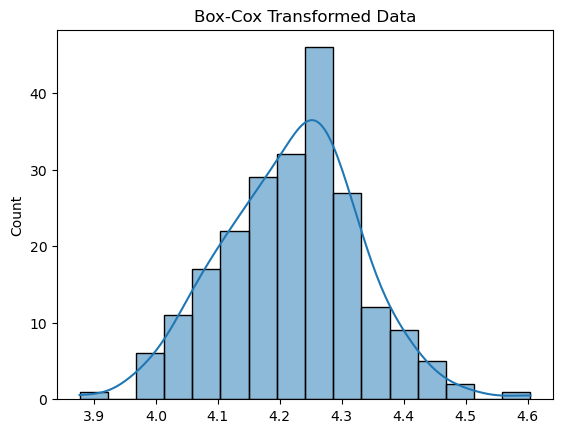

In [51]:
# Box-Cox Transformation
transformed_data, lambda_ = stats.boxcox(df['transaction_amount'] + 1)

sns.histplot(transformed_data, kde=True)
plt.title("Box-Cox Transformed Data")
plt.show()

In [52]:
# Z-score & Probability > ₹5000
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()

z = (5000 - mean) / std

prob = 1 - stats.norm.cdf(z)

print("Probability of transactions > 5000:", prob)

Probability of transactions > 5000: 0.20517209567554384


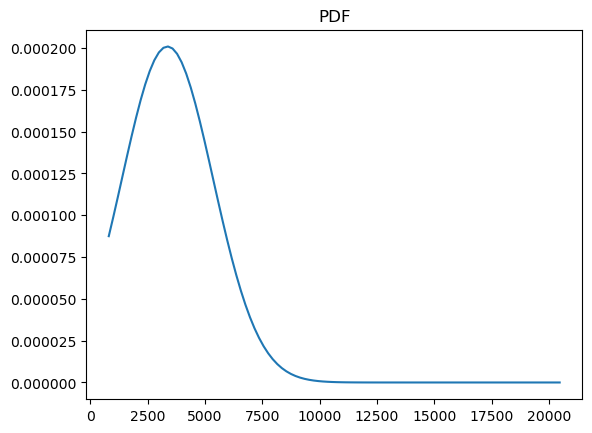

In [53]:
# PDF 
x = np.linspace(min(df['transaction_amount']), max(df['transaction_amount']), 100)

pdf = stats.norm.pdf(x, mean, std)

plt.plot(x, pdf)
plt.title("PDF")
plt.show()

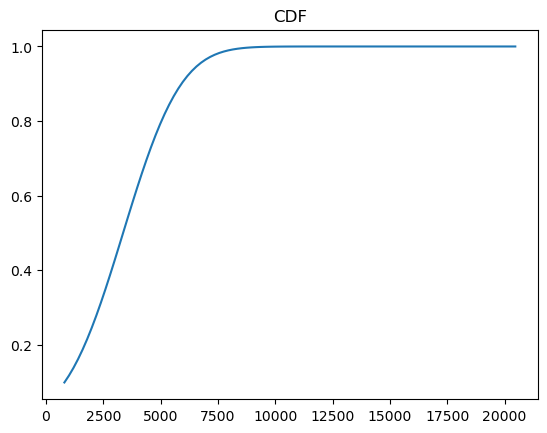

In [54]:
# CDF
cdf = stats.norm.cdf(x, mean, std)

plt.plot(x, cdf)
plt.title("CDF")
plt.show()